In [71]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import svm
from sklearn.svm import SVC
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from sklearn.pipeline import make_pipeline
from sklearn.datasets import make_classification, make_moons
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Generate dataset

In [73]:
X, y = make_classification( n_samples=2502,
                            random_state=259202,
                            n_features=2,
                            n_informative=2,
                            n_redundant=0,
                            n_repeated=0,
                            class_sep=2)
Xm, ym = make_moons(n_samples=2502, random_state=259202)

In [74]:
X.shape, y.shape, Xm.shape, ym.shape

((2502, 2), (2502,), (2502, 2), (2502,))

In [75]:
def plot_data(X, y, title=""):
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

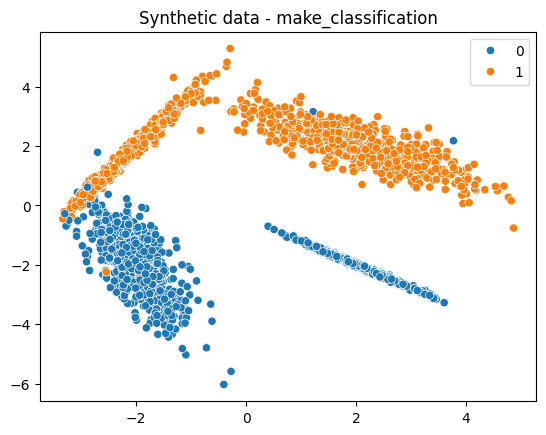

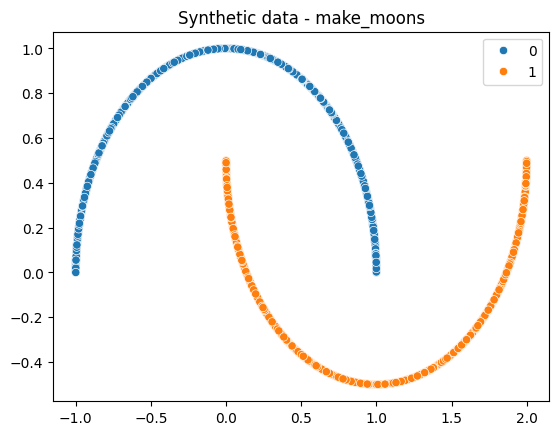

In [76]:
plot_data(X, y, "Synthetic data - make_classification")
plot_data(Xm, ym, "Synthetic data - make_moons")

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=295202)
Xm_train, Xm_test, ym_train, ym_test = train_test_split(Xm, ym, random_state=295202)

In [78]:
def plot_decision_boundary(X, y, w, b, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = b + w[0] * xx + w[1] * yy
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z > 0, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

In [79]:
def plot_decision_boundary_clf(X, y, clf, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z > 0, alpha=0.3)

    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')

    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.title(title)
    plt.show()

# Implementation of linear SVM

In [80]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

scaler_moons = StandardScaler()
Xm_train_scaled = scaler_moons.fit_transform(Xm_train)
Xm_test_scaled = scaler_moons.transform(Xm_test)

In [81]:
y_train_scaled = np.where(y_train == 1, 1, -1)
ym_train_scaled = np.where(ym_train == 1, 1, -1)
y_train_scaled, ym_train_scaled

(array([ 1,  1, -1, ...,  1, -1,  1]), array([ 1, -1,  1, ...,  1, -1, -1]))

In [82]:
X_train_scaled.shape, y_train_scaled.shape

((1876, 2), (1876,))

In [83]:
K = X_train_scaled @ X_train_scaled.T
Y = y_train_scaled.reshape(-1, 1) @ y_train_scaled.reshape(-1, 1).T
K.shape, Y.shape

((1876, 1876), (1876, 1876))

In [84]:
n = X_train_scaled.shape[0]
YK = Y * K

def obj(lam):
    # dual: L(lam) = sum(lam) − 0.5 * lam @ (Y*K) lam
    return -(lam.sum() - 0.5 * lam @ YK @ lam)

cons = {'type': 'eq', 'fun': lambda lam: lam @ y_train_scaled} # ensure sum(lam_i * y_i) = 0
bounds = [(0, None)] * n

# initial guess
lam0 = np.ones(n)

res = minimize(obj,
               x0=lam0,
               bounds=bounds,
               constraints=cons,
               options={'maxiter':5, 'disp':True})

Iteration limit reached    (Exit mode 9)
            Current function value: -68036.45416388262
            Iterations: 5
            Function evaluations: 9389
            Gradient evaluations: 5


In [85]:
lams = res.x

# support vectors mask
sv = lams > 1e-6

w = (lams * y_train_scaled) @ X_train_scaled
b = np.mean(y_train_scaled[sv] - X_train_scaled[sv] @ w)

def predict(X):
    return np.sign(X @ w + b) # -1 or 1

def predict_proba(X):
    return (X @ w + b) # probability

y_test_scaled = np.where(y_test==1, 1, -1)
y_pred = predict(X_test_scaled)

accuracy_impl = accuracy_score(y_test_scaled, y_pred)
print(f"Implemented SVM accuracy: {accuracy_impl}")

Implemented SVM accuracy: 0.9840255591054313


In [171]:
def train_impl_svm(X_train, y_train, kernel='linear', degree=3, maxiter=5, gamma=1):

    y = np.where(y_train == 1, 1, -1)
    n = X_train.shape[0]
    
    
    if kernel == 'linear':
        K = X_train @ X_train.T
    elif kernel == 'rbf': # exp(-gamma * ||x - xi||^2)
        D2 = np.sum((X_train[:,None,:] - X_train[None,:,:])**2, axis=2) # pairwise squared distance
        K = np.exp(-gamma * D2)
    elif kernel == 'poly':
        alpha = 1.0 / X_train.shape[1]
        K = (alpha * (X_train @ X_train.T) + 1) ** degree
    else:
        raise ValueError("Unsupported kernel")

    
    Y = y.reshape(-1,1) @ y.reshape(1,-1)
    YK = Y * K

    def obj(lam):
        # dual objective (negated for minimizer)
        return -(lam.sum() - 0.5 * lam @ YK @ lam)

    cons = {'type':'eq', 'fun': lambda lam: lam @ y}
    bounds = [(0, 50)] * n # C - upper bound on lam_i
    lam0 = np.ones(n)

    res = minimize(obj,
                   x0=lam0,
                   bounds=bounds,
                   constraints=cons,
                   options={'maxiter': maxiter, 'disp': False})
    lams = res.x
    sv_mask = lams > 1e-6

    b = np.mean(y[sv_mask] - (YK[sv_mask] @ lams))

    return {
      'kernel':  kernel,
      'w':       (lams * y) @ X_train if kernel=='linear' else None,
      'b':       b,
      'lams':    lams[sv_mask],
      'X_sv':    X_train[sv_mask],
      'y_sv':    y[sv_mask],
      'degree':  degree,
      'gamma':   gamma
    }


def predict_impl_svm(model, X):
    kernel = model['kernel']
    
    X_sv  = model['X_sv']
    y_sv  = model['y_sv']
    lams  = model['lams']
    b = model['b']
    
    if kernel == 'linear':
        scores = X @ model['w'] + b
        
    elif kernel == 'rbf':
        D2_test = np.sum((X[:,None,:] - X_sv[None,:,:])**2, axis=2)
        K_test  = np.exp(-model['gamma'] * D2_test)
        scores = K_test.dot(lams * y_sv) + b
        
    elif kernel == 'poly':
        alpha = 1.0 / X_train.shape[1]
        K_test  = (alpha * (X @ X_sv.T) + 1)**model['degree']
        scores = K_test.dot(lams * y_sv) + b
        
        
    return np.sign(scores), scores

In [172]:
model_linear = train_impl_svm(X_train_scaled, y_train, kernel='linear')
model_rbf = train_impl_svm(X_train_scaled, y_train, kernel='rbf', gamma=1)
model_poly = train_impl_svm(X_train_scaled, y_train, kernel='poly', degree=3)

model_moons_linear = train_impl_svm(Xm_train_scaled, ym_train, kernel='linear')
model_moons_rbf = train_impl_svm(Xm_train_scaled, ym_train, kernel='rbf', gamma=1)
model_moons_poly = train_impl_svm(Xm_train_scaled, ym_train, kernel='poly', degree=3)

In [173]:
y_test_scaled = np.where(y_test==1, 1, -1)
ym_test_scaled = np.where(ym_test==1, 1, -1)

y_pred_impl_linear, y_score_impl_linear = predict_impl_svm(model_linear, X_test_scaled)
y_pred_impl_rbf, y_score_impl_rbf = predict_impl_svm(model_rbf, X_test_scaled)
y_pred_impl_poly, y_score_impl_poly = predict_impl_svm(model_poly, X_test_scaled)
accuracy_impl_linear = accuracy_score(y_test_scaled, y_pred_impl_linear)
accuracy_impl_rbf = accuracy_score(y_test_scaled, y_pred_impl_rbf)
accuracy_impl_poly = accuracy_score(y_test_scaled, y_pred_impl_poly)

y_pred_impl_moons_linear, y_score_impl_moons_linear = predict_impl_svm(model_moons_linear, Xm_test_scaled)
y_pred_impl_moons_rbf, y_score_impl_moons_rbf = predict_impl_svm(model_moons_rbf, Xm_test_scaled)
y_pred_impl_moons_poly, y_score_impl_moons_poly = predict_impl_svm(model_moons_poly, Xm_test_scaled)
accuracy_impl_moons_linear = accuracy_score(ym_test_scaled, y_pred_impl_moons_linear)
accuracy_impl_moons_rbf = accuracy_score(ym_test_scaled, y_pred_impl_moons_rbf)
accuracy_impl_moons_poly = accuracy_score(ym_test_scaled, y_pred_impl_moons_poly)


print(f"Implemented SVM accuracy (linear): {accuracy_impl_linear}")
print(f"Implemented SVM accuracy (rbf): {accuracy_impl_rbf}")
print(f"Implemented SVM accuracy (poly): {accuracy_impl_poly}")
print('-'*50)
print(f"Implemented SVM accuracy (moons linear): {accuracy_impl_moons_linear}")
print(f"Implemented SVM accuracy (moons rbf): {accuracy_impl_moons_rbf}")
print(f"Implemented SVM accuracy (moons poly): {accuracy_impl_moons_poly}")

Implemented SVM accuracy (linear): 0.6405750798722045
Implemented SVM accuracy (rbf): 0.4952076677316294
Implemented SVM accuracy (poly): 0.6261980830670927
--------------------------------------------------
Implemented SVM accuracy (moons linear): 0.2012779552715655
Implemented SVM accuracy (moons rbf): 0.7843450479233227
Implemented SVM accuracy (moons poly): 0.5287539936102237


In [174]:
print("Unique polynomial predictions:", np.unique(y_pred_impl_poly, return_counts=True))
print("Actual class distribution:", np.unique(y_test_scaled, return_counts=True))

Unique polynomial predictions: (array([-1.,  1.]), array([229, 397], dtype=int64))
Actual class distribution: (array([-1,  1]), array([329, 297], dtype=int64))


In [97]:
def plot_decision_boundary_general(X, y, model, custom=False, title=""):
    h = 0.02
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    if custom:
        # predict_impl_svm returns (pred, score)
        _, Z = predict_impl_svm(model, pts)
    else:
        Z = model.decision_function(pts)

    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z>0, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

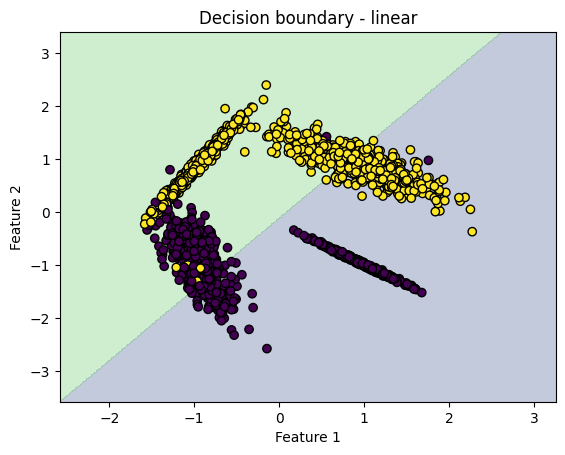

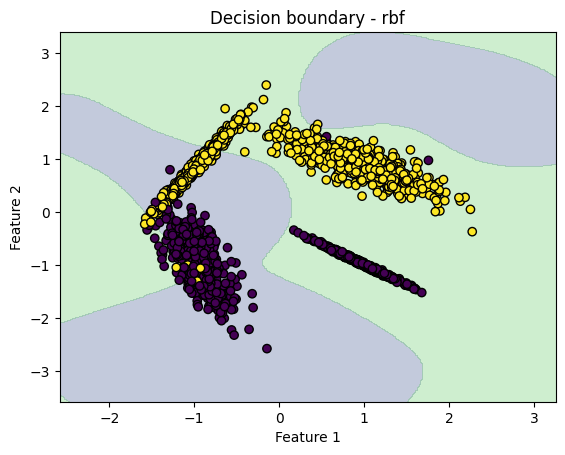

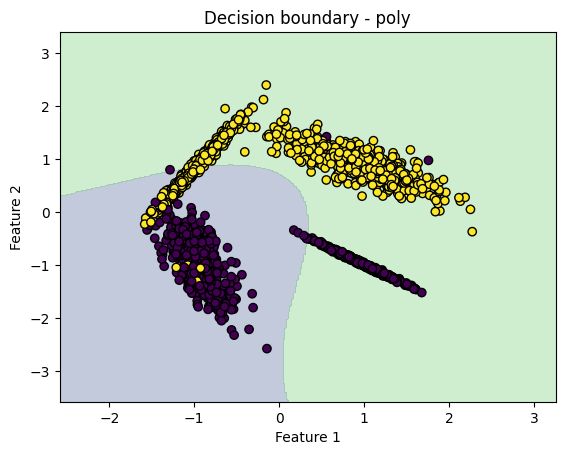

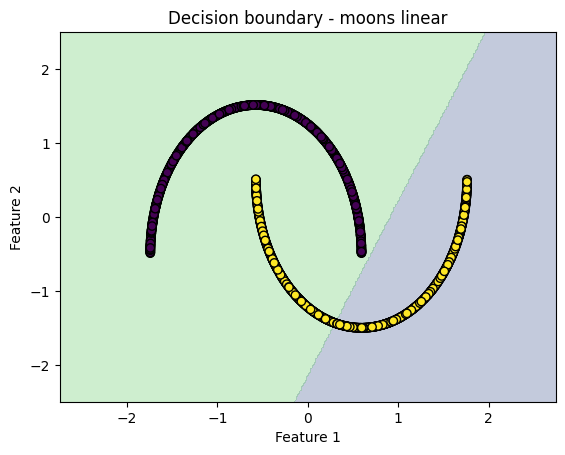

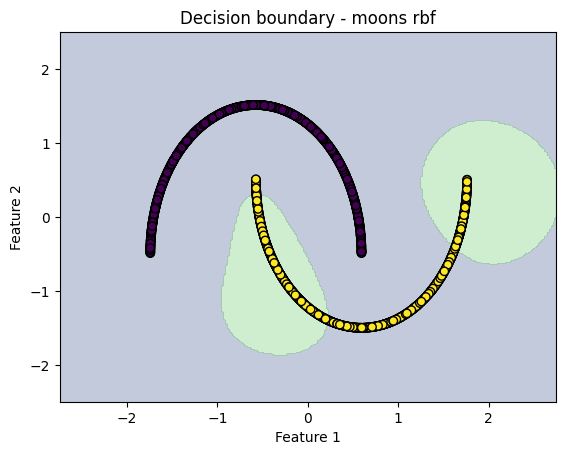

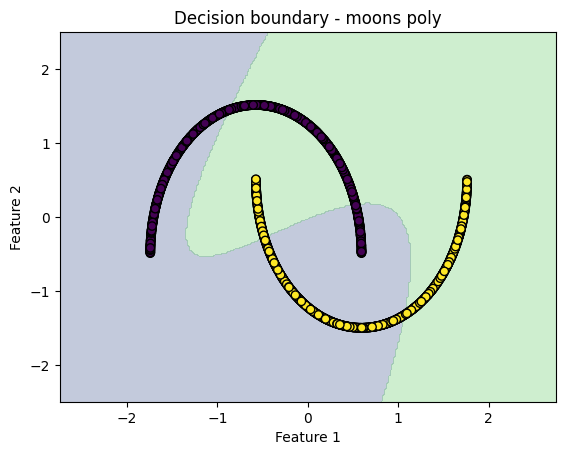

In [175]:
plot_decision_boundary_general(X_train_scaled, y_train_scaled, model_linear, custom=True, title="Decision boundary - linear")
plot_decision_boundary_general(X_train_scaled, y_train_scaled, model_rbf, custom=True, title="Decision boundary - rbf")
plot_decision_boundary_general(X_train_scaled, y_train_scaled, model_poly, custom=True, title="Decision boundary - poly")
plot_decision_boundary_general(Xm_train_scaled, ym_train_scaled, model_moons_linear, custom=True, title="Decision boundary - moons linear")
plot_decision_boundary_general(Xm_train_scaled, ym_train_scaled, model_moons_rbf, custom=True, title="Decision boundary - moons rbf")
plot_decision_boundary_general(Xm_train_scaled, ym_train_scaled, model_moons_poly, custom=True, title="Decision boundary - moons poly")

# Sklearn SVM SVC

kerlen = linear

In [99]:
clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))
clf.fit(X_train, y_train)
y_pred_skl_linear = clf.predict(X_test)
y_score_skl_linear = clf.decision_function(X_test)
accuracy_skl_linear = accuracy_score(y_test, y_pred_skl_linear)

clf_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
clf_rbf.fit(X_train, y_train)
y_pred_skl_rbf = clf_rbf.predict(X_test)
y_score_skl_rbf = clf_rbf.decision_function(X_test)
accuracy_skl_rbf = accuracy_score(y_test, y_pred_skl_rbf)

clf_poly = make_pipeline(StandardScaler(), SVC(kernel='poly'))
clf_poly.fit(X_train, y_train)
y_pred_skl_poly = clf_poly.predict(X_test)
y_score_skl_poly = clf_poly.decision_function(X_test)
accuracy_skl_poly = accuracy_score(y_test, y_pred_skl_poly)

clfm = make_pipeline(StandardScaler(), SVC(kernel='linear'))
clfm.fit(Xm_train, ym_train)
ym_pred_skl_linear = clfm.predict(Xm_test)
ym_score_skl_linear = clfm.decision_function(Xm_test)
accuracy_skl_moons_linear = accuracy_score(ym_test, ym_pred_skl_linear)

clfm_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
clfm_rbf.fit(Xm_train, ym_train)
ym_pred_skl_rbf = clfm_rbf.predict(Xm_test)
ym_score_skl_rbf = clfm_rbf.decision_function(Xm_test)
accuracy_skl_moons_rbf = accuracy_score(ym_test, ym_pred_skl_rbf)

clfm_poly = make_pipeline(StandardScaler(), SVC(kernel='poly'))
clfm_poly.fit(Xm_train, ym_train)
ym_pred_skl_poly = clfm_poly.predict(Xm_test)
ym_score_skl_poly = clfm_poly.decision_function(Xm_test)
accuracy_skl_moons_poly = accuracy_score(ym_test, ym_pred_skl_poly)

In [100]:
print(f"Accuracy SVC - linear - make_classification: {accuracy_skl_linear}")
print(f"Accuracy SVC - rbf - make_classification: {accuracy_skl_rbf}")
print(f"Accuracy SVC - poly - make_classification: {accuracy_skl_poly}")
print()
print(f"Accuracy score SVC - linear - make_moons: {accuracy_skl_moons_linear}")
print(f"Accuracy score SVC - rbf - make_moons: {accuracy_skl_moons_rbf}")
print(f"Accuracy score SVC - poly - make_moons: {accuracy_skl_moons_poly}")

Accuracy SVC - linear - make_classification: 0.9952076677316294
Accuracy SVC - rbf - make_classification: 0.9952076677316294
Accuracy SVC - poly - make_classification: 0.9952076677316294

Accuracy score SVC - linear - make_moons: 0.8945686900958466
Accuracy score SVC - rbf - make_moons: 1.0
Accuracy score SVC - poly - make_moons: 0.8977635782747604


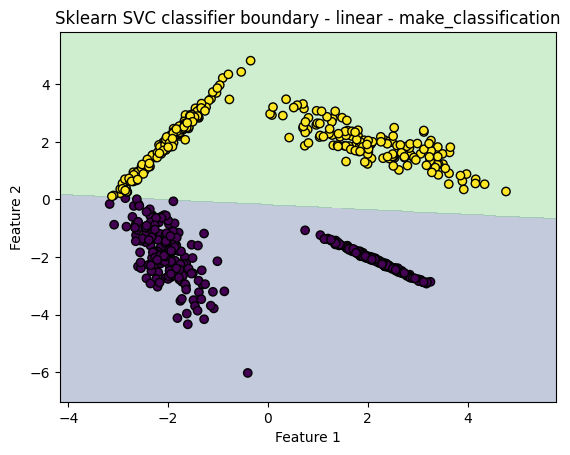

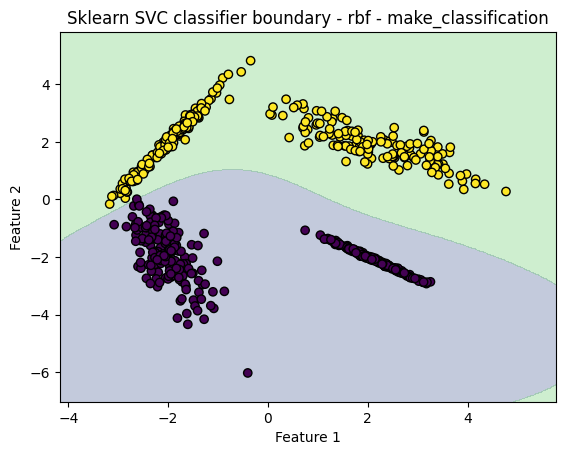

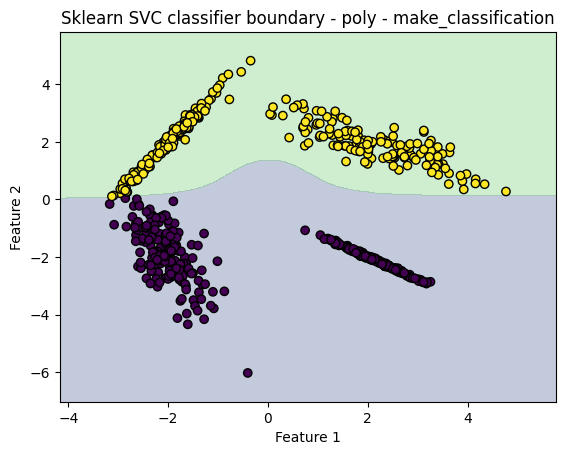

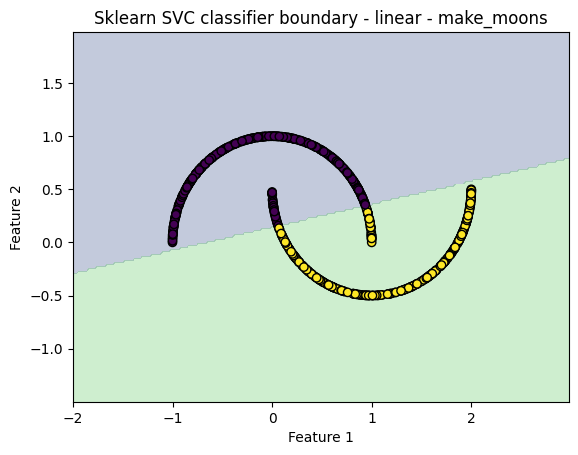

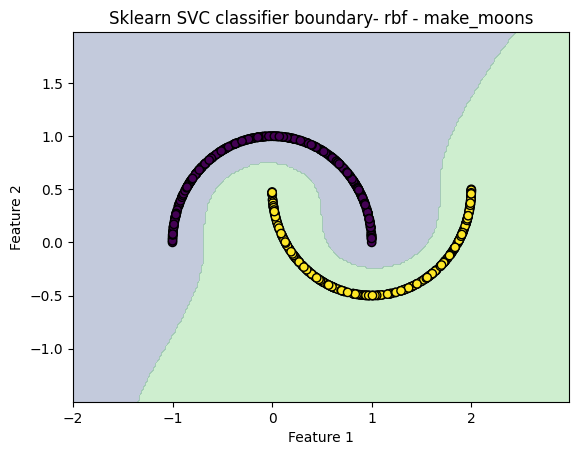

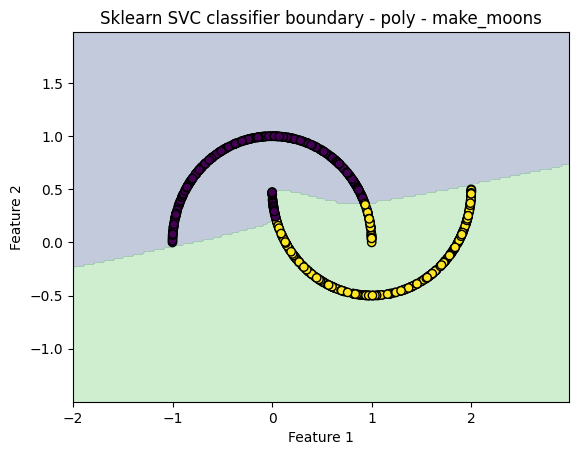

In [101]:
plot_decision_boundary_clf(X_test, y_pred_skl_linear, clf, "Sklearn SVC classifier boundary - linear - make_classification")
plot_decision_boundary_clf(X_test, y_pred_skl_rbf, clf_rbf, "Sklearn SVC classifier boundary - rbf - make_classification")
plot_decision_boundary_clf(X_test, y_pred_skl_poly, clf_poly, "Sklearn SVC classifier boundary - poly - make_classification")
plot_decision_boundary_clf(Xm_test, ym_pred_skl_linear, clfm, "Sklearn SVC classifier boundary - linear - make_moons")
plot_decision_boundary_clf(Xm_test, ym_pred_skl_rbf, clfm_rbf, "Sklearn SVC classifier boundary- rbf - make_moons")
plot_decision_boundary_clf(Xm_test, ym_pred_skl_poly, clfm_poly, "Sklearn SVC classifier boundary - poly - make_moons")

# Evaluation

In [116]:
start_time = time.time()
for _ in range(10):
    clf = make_pipeline(StandardScaler(), SVC(kernel='linear'))
    clf.fit(X_train, y_train)
sklearn_time_linear = time.time() - start_time

start_time = time.time()
for _ in range(10):
    clf_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf'))
    clf_rbf.fit(X_train, y_train)
sklearn_time_rbf = time.time() - start_time

start_time = time.time()
for _ in range(10):
    clf_poly = make_pipeline(StandardScaler(), SVC(kernel='poly'))
    clf_poly.fit(X_train, y_train)
sklearn_time_poly = time.time() - start_time

start_time = time.time()
for _ in range(10):
    _ = train_impl_svm(X_train_scaled, y_train, kernel='linear')
implemented_time_linear = time.time() - start_time

start_time = time.time()
for _ in range(10):
    _ = train_impl_svm(X_train_scaled, y_train, kernel='rbf')
implemented_time_rbf = time.time() - start_time

start_time = time.time()
for _ in range(10):
    _ = train_impl_svm(X_train_scaled, y_train, kernel='poly')
implemented_time_poly = time.time() - start_time

In [118]:
print(f"Sklearn training time linear: {sklearn_time_linear/10:.6f} s")
print(f"Sklearn training time rbf: {sklearn_time_rbf/10:.6f} s")
print(f"Sklearn training time poly: {sklearn_time_poly/10:.6f} s")
print()
print(f"Implemented training time linear: {implemented_time_linear/10:.6f} s")
print(f"Implemented training time rbf: {implemented_time_rbf/10:.6f} s")
print(f"Implemented training time poly: {implemented_time_poly/10:.6f} s")

Sklearn training time linear: 0.006044 s
Sklearn training time rbf: 0.005200 s
Sklearn training time poly: 0.006013 s

Implemented training time linear: 48.865454 s
Implemented training time rbf: 75.750844 s
Implemented training time poly: 93.178964 s


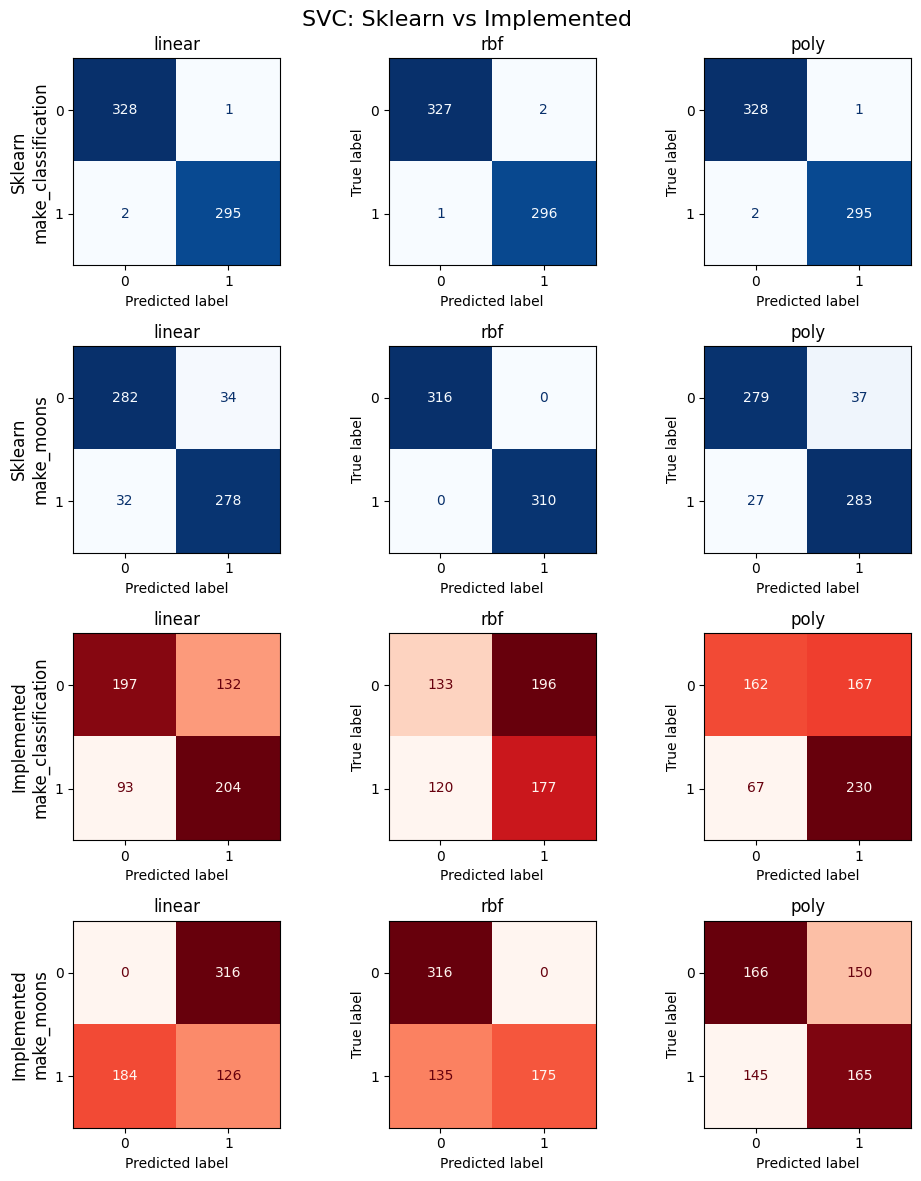

In [176]:
cms = {}

figure, axes = plt.subplots(4, 3, figsize=(10,12))
plt.suptitle("SVC: Sklearn vs Implemented", fontsize=16)

# row 0: Sklearn, make_classification
cm = confusion_matrix(y_test, y_pred_skl_linear)
ConfusionMatrixDisplay(cm).plot(ax=axes[0,0], cmap='Blues', colorbar=None)
axes[0,0].set_title("linear")
cms['sklearn_linear'] = cm

cm = confusion_matrix(y_test, y_pred_skl_rbf)
ConfusionMatrixDisplay(cm).plot(ax=axes[0,1], cmap='Blues', colorbar=None)
axes[0,1].set_title("rbf")
cms['sklearn_rbf'] = cm

cm = confusion_matrix(y_test, y_pred_skl_poly)
ConfusionMatrixDisplay(cm).plot(ax=axes[0,2], cmap='Blues', colorbar=None)
axes[0,2].set_title("poly")
cms['sklearn_poly'] = cm

# row 1: Sklearn, make_moons
cm = confusion_matrix(ym_test, ym_pred_skl_linear)
ConfusionMatrixDisplay(cm).plot(ax=axes[1,0], cmap='Blues', colorbar=None)
axes[1,0].set_title("linear")
cms['sklearn_moons_linear'] = cm

cm = confusion_matrix(ym_test, ym_pred_skl_rbf)
ConfusionMatrixDisplay(cm).plot(ax=axes[1,1], cmap='Blues', colorbar=None)
axes[1,1].set_title("rbf")
cms['sklearn_moons_rbf'] = cm

cm = confusion_matrix(ym_test, ym_pred_skl_poly)
ConfusionMatrixDisplay(cm).plot(ax=axes[1,2], cmap='Blues', colorbar=None)
axes[1,2].set_title("poly")
cms['sklearn_moons_poly'] = cm

# row 2: Implemented, make_classification
cm = confusion_matrix(y_test_scaled, y_pred_impl_linear)
ConfusionMatrixDisplay(cm).plot(ax=axes[2,0], cmap='Reds', colorbar=None)
axes[2,0].set_title("linear")
cms['impl_linear'] = cm

cm = confusion_matrix(y_test_scaled, y_pred_impl_rbf)
ConfusionMatrixDisplay(cm).plot(ax=axes[2,1], cmap='Reds', colorbar=None)
axes[2,1].set_title("rbf")
cms['impl_rbf'] = cm

cm = confusion_matrix(y_test_scaled, y_pred_impl_poly)
ConfusionMatrixDisplay(cm).plot(ax=axes[2,2], cmap='Reds', colorbar=None)
axes[2,2].set_title("poly")
cms['impl_poly'] = cm

# row 3: Implemented, make_moons
cm = confusion_matrix(ym_test_scaled, y_pred_impl_moons_linear)
ConfusionMatrixDisplay(cm).plot(ax=axes[3,0], cmap='Reds', colorbar=None)
axes[3,0].set_title("linear")
cms['impl_moons_linear'] = cm

cm = confusion_matrix(ym_test_scaled, y_pred_impl_moons_rbf)
ConfusionMatrixDisplay(cm).plot(ax=axes[3,1], cmap='Reds', colorbar=None)
axes[3,1].set_title("rbf")
cms['impl_moons_rbf'] = cm

cm = confusion_matrix(ym_test_scaled, y_pred_impl_moons_poly)
ConfusionMatrixDisplay(cm).plot(ax=axes[3,2], cmap='Reds', colorbar=None)
axes[3,2].set_title("poly")
cms['impl_moons_poly'] = cm

axes[0,0].set_ylabel("Sklearn\nmake_classification", fontsize=12)
axes[1,0].set_ylabel("Sklearn\nmake_moons", fontsize=12)
axes[2,0].set_ylabel("Implemented\nmake_classification", fontsize=12)
axes[3,0].set_ylabel("Implemented\nmake_moons", fontsize=12)

plt.tight_layout()
plt.show()

In [177]:
stats_df = pd.DataFrame(columns=['tn', 'fp', 'fn', 'tp', 'specificity', 'sensitivity'])
for cm in cms:
    tn, fp, fn, tp = cms[cm].ravel()
    specificity = tn / (tn+fp) # swoistosc
    sensitivity = tp / (tp+fn) # czulosc
    stats_df.loc[cm] = [tn, fp, fn, tp, specificity, sensitivity]
stats_df = stats_df.round(3)
stats_df

,tn,fp,fn,tp,specificity,sensitivity
sklearn_linear,328.0,1.0,2.0,295.0,0.997,0.993
sklearn_rbf,327.0,2.0,1.0,296.0,0.994,0.997
sklearn_poly,328.0,1.0,2.0,295.0,0.997,0.993
sklearn_moons_linear,282.0,34.0,32.0,278.0,0.892,0.897
sklearn_moons_rbf,316.0,0.0,0.0,310.0,1.000,1.000
sklearn_moons_poly,279.0,37.0,27.0,283.0,0.883,0.913
impl_linear,197.0,132.0,93.0,204.0,0.599,0.687
impl_rbf,133.0,196.0,120.0,177.0,0.404,0.596
impl_poly,162.0,167.0,67.0,230.0,0.492,0.774
impl_moons_linear,0.0,316.0,184.0,126.0,0.000,0.406


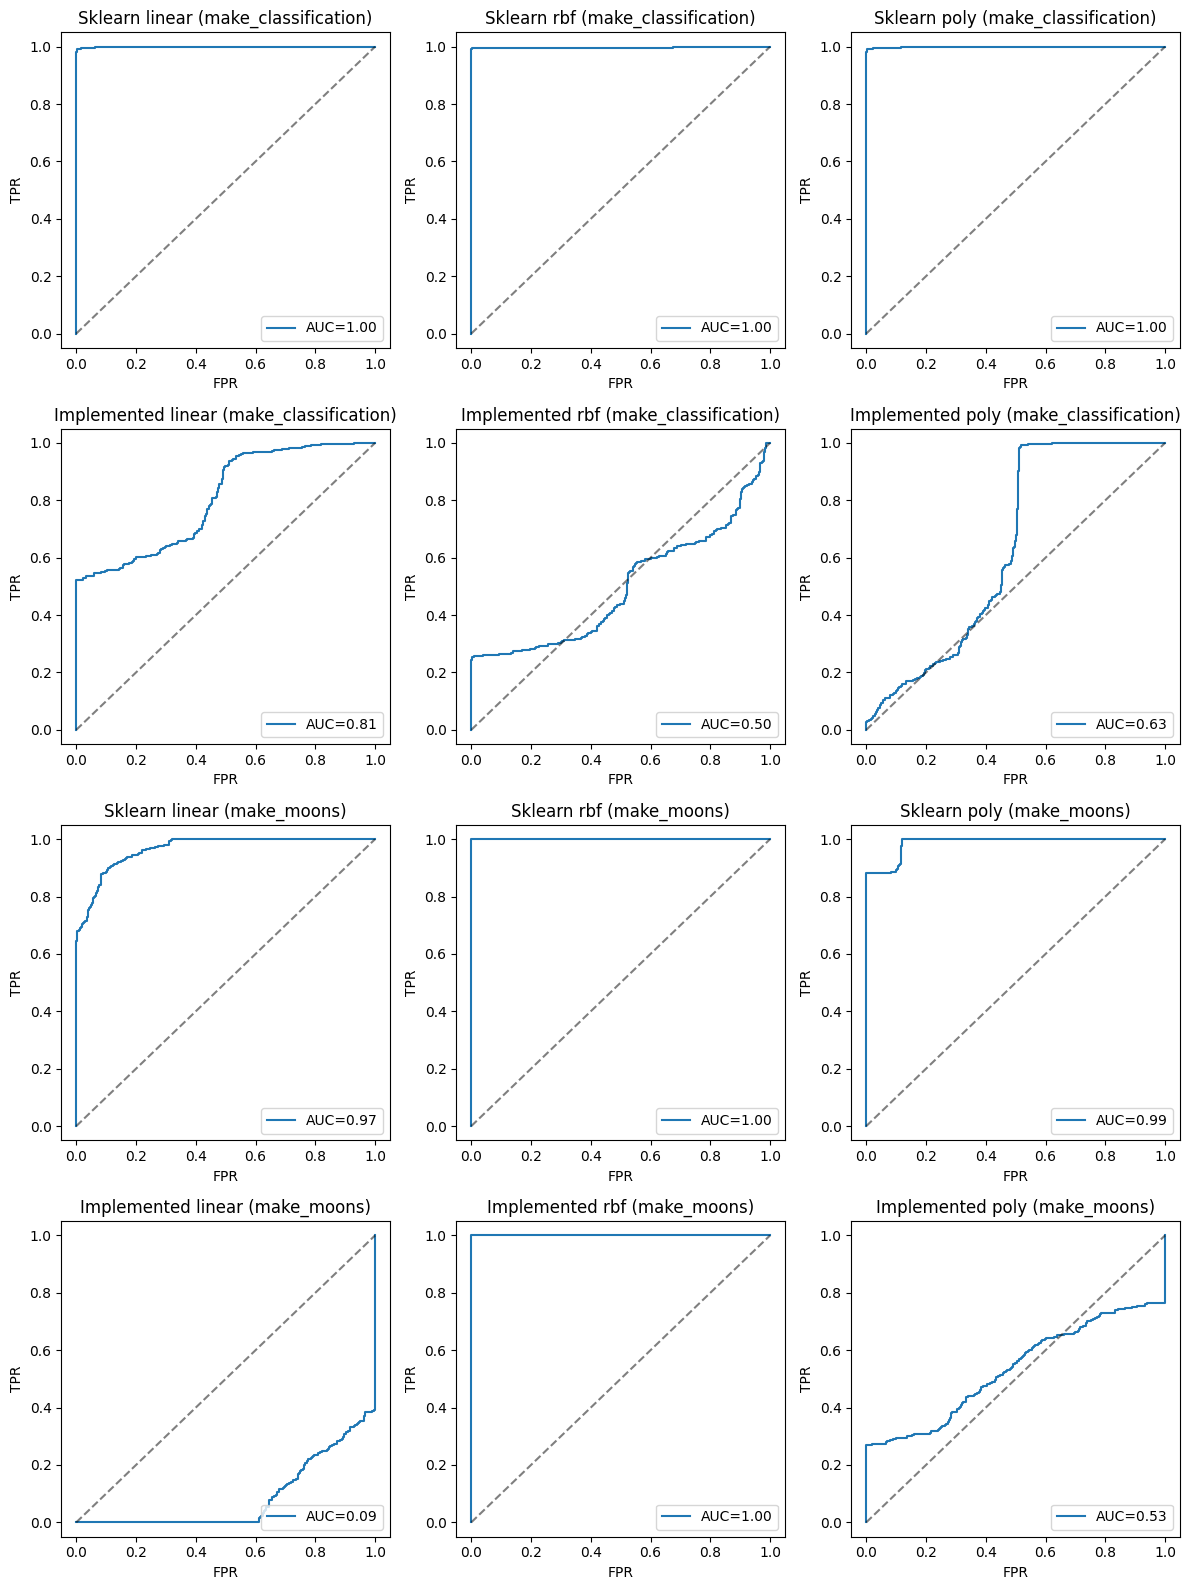

In [ ]:
roc_map = {
    ("Sklearn",     "linear", "make_classification"): (y_test,          y_score_skl_linear),
    ("Sklearn",     "rbf",    "make_classification"): (y_test,          y_score_skl_rbf),
    ("Sklearn",     "poly",   "make_classification"): (y_test,          y_score_skl_poly),
    ("Implemented", "linear", "make_classification"): (y_test_scaled,   y_score_impl_linear),
    ("Implemented", "rbf",    "make_classification"): (y_test_scaled,   y_score_impl_rbf),
    ("Implemented", "poly",   "make_classification"): (y_test_scaled,   y_score_impl_poly),
    ("Sklearn",     "linear", "make_moons"):          (ym_test,         ym_score_skl_linear),
    ("Sklearn",     "rbf",    "make_moons"):          (ym_test,         ym_score_skl_rbf),
    ("Sklearn",     "poly",   "make_moons"):          (ym_test,         ym_score_skl_poly),
    ("Implemented", "linear", "make_moons"):          (ym_test_scaled,  y_score_impl_moons_linear),
    ("Implemented", "rbf",    "make_moons"):          (ym_test_scaled,  y_score_impl_moons_rbf),
    ("Implemented", "poly",   "make_moons"):          (ym_test_scaled,  y_score_impl_moons_poly),
}

fig, axes = plt.subplots(4, 3, figsize=(12, 16))
for ax, key in zip(axes.flatten(), roc_map):
    lib, kern, ds = key
    y_true, y_score = roc_map[key]
    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    ax.set_title(f"{lib} {kern} ({ds})")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.legend(loc="lower right")

plt.tight_layout()
plt.show()

# Stellar Classification Dataset - SDSS17

In [3]:
data = pd.read_csv('/content/star_classification.csv', on_bad_lines='skip')
data

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,1.237679e+18,39.620709,-2.594074,22.16759,22.97586,21.90404,21.30548,20.73569,7778,301,2,581,1.055431e+19,GALAXY,0.000000,9374,57749,438
99996,1.237679e+18,29.493819,19.798874,22.69118,22.38628,20.45003,19.75759,19.41526,7917,301,1,289,8.586351e+18,GALAXY,0.404895,7626,56934,866
99997,1.237668e+18,224.587407,15.700707,21.16916,19.26997,18.20428,17.69034,17.35221,5314,301,4,308,3.112008e+18,GALAXY,0.143366,2764,54535,74
99998,1.237661e+18,212.268621,46.660365,25.35039,21.63757,19.91386,19.07254,18.62482,3650,301,4,131,7.601080e+18,GALAXY,0.455040,6751,56368,470


In [4]:
data.shape, data.columns.values

((100000, 18),
 array(['obj_ID', 'alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'run_ID',
        'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'class',
        'redshift', 'plate', 'MJD', 'fiber_ID'], dtype=object))

In [5]:
# remove irrelevant columns
data = data.drop(columns=["obj_ID", # Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
                          "run_ID", # identify the specific scan
                          "rerun_ID", # specify how the image was processed
                          "cam_col", # identify the scanline within the run
                          "field_ID", # identify each field
                          "spec_obj_ID", # used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
                          "MJD", # indicate when a given piece of SDSS data was taken
                          "fiber_ID" # identifies the fiber that pointed the light at the focal plane in each observation
                          ])

In [6]:
data.shape

(100000, 10)

In [7]:
X, y = data.drop(columns=["class"]), data["class"]
X.shape, y.shape

((100000, 9), (100000,))

In [8]:
y.unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [9]:
X.isna().sum()

,0
alpha,0
delta,0
u,0
g,0
r,0
i,0
z,0
redshift,0
plate,0


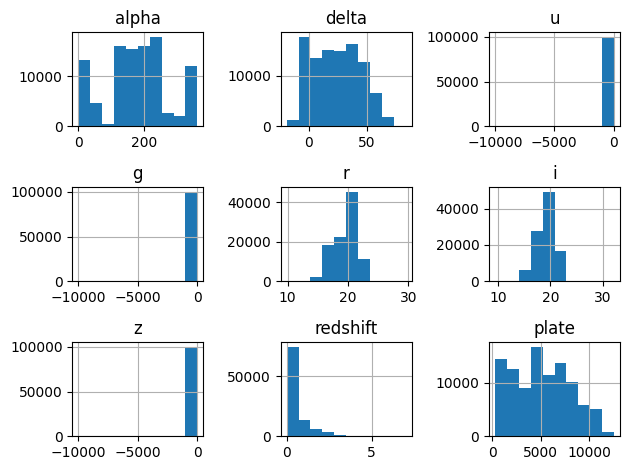

In [10]:
X.hist()
plt.tight_layout()

In [11]:
X['g'].min(), X['g'].max()

(-9999.0, 31.60224)

In [12]:
# winsorizing the data that outlies more than 1.5 IQR
for col in ['u', 'g', 'z']:
    q1, q3 = np.quantile(X[col], [0.25,0.75]) # quantiles
    iqr = q3 - q1
    lb, ub = q1 - 1.5*iqr, q3 + 1.5*iqr
    X[col] = np.clip(X[col], lb, ub)

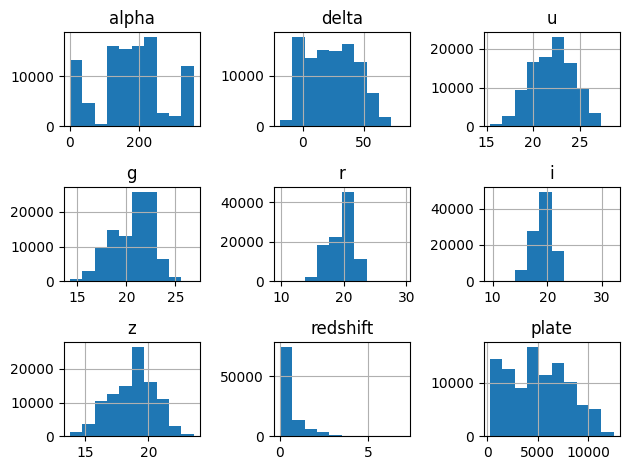

In [13]:
X.hist()
plt.tight_layout()

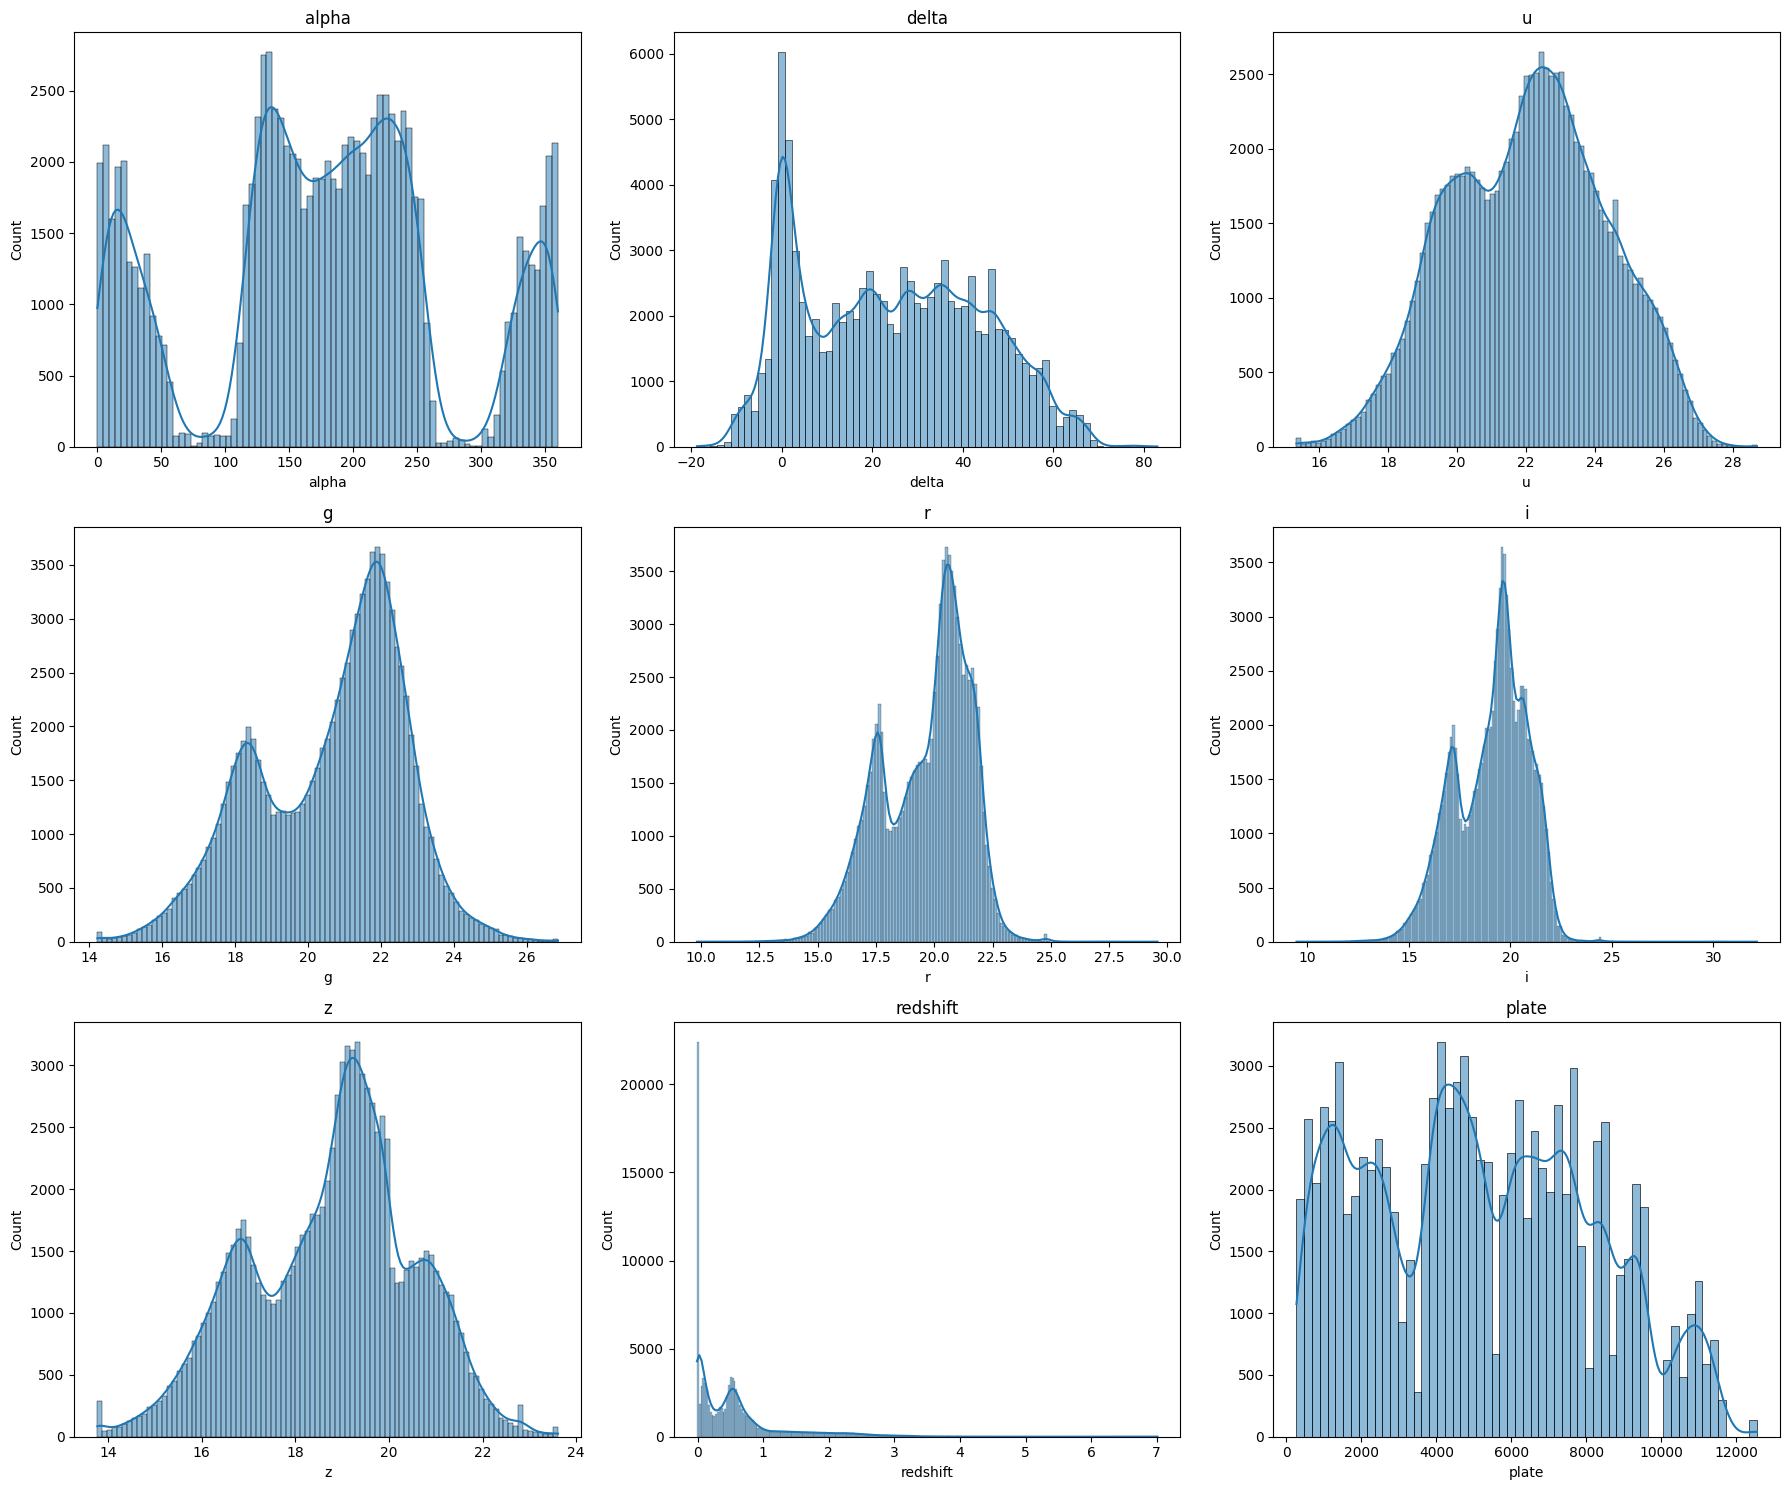

In [14]:
def plot_histograms(X):
    plt.figure(figsize=(18, 15))
    for i, col in enumerate(X.columns):
        plt.subplot(3, 3, i+1)
        sns.histplot(data=X, x=col, kde=True)
        plt.title(col)
    plt.tight_layout()
    plt.show()
plot_histograms(X)

In [15]:
X['redshift'].min(), X['redshift'].max()

(-0.009970667, 7.011245)

As we can see from the distribution, we cannot standarize the data, because the data distribiution is not normal.

In [16]:
class_map = {"STAR": 0, "GALAXY": 1, "QSO": 2}
y = y.map(class_map)
y.unique()

array([1, 2, 0])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=259202)

In [18]:
X_train.shape, X_test.shape

((75000, 9), (25000, 9))

In [19]:
def corr_matrix_plot(X_train, y_train):
    X_corr = X_train.copy()
    X_corr['target'] = y_train
    corr_matrix = X_corr.corr()

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f')

    plt.title('Correlation Matrix of SDSS17')
    plt.tight_layout()
    plt.show()

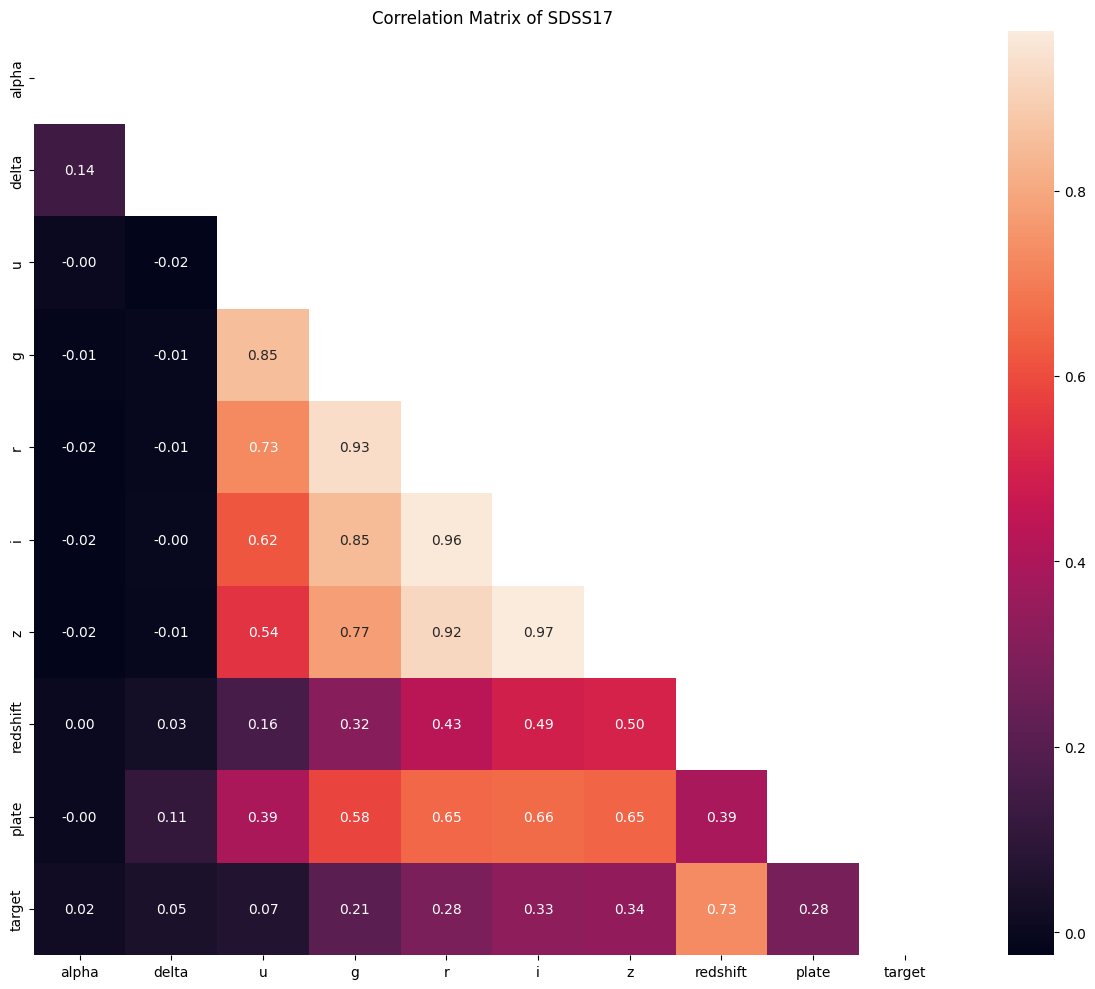

In [20]:
corr_matrix_plot(X_train, y_train)

In [21]:
# normalization
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train)
X_test_normalized = scaler.transform(X_test)

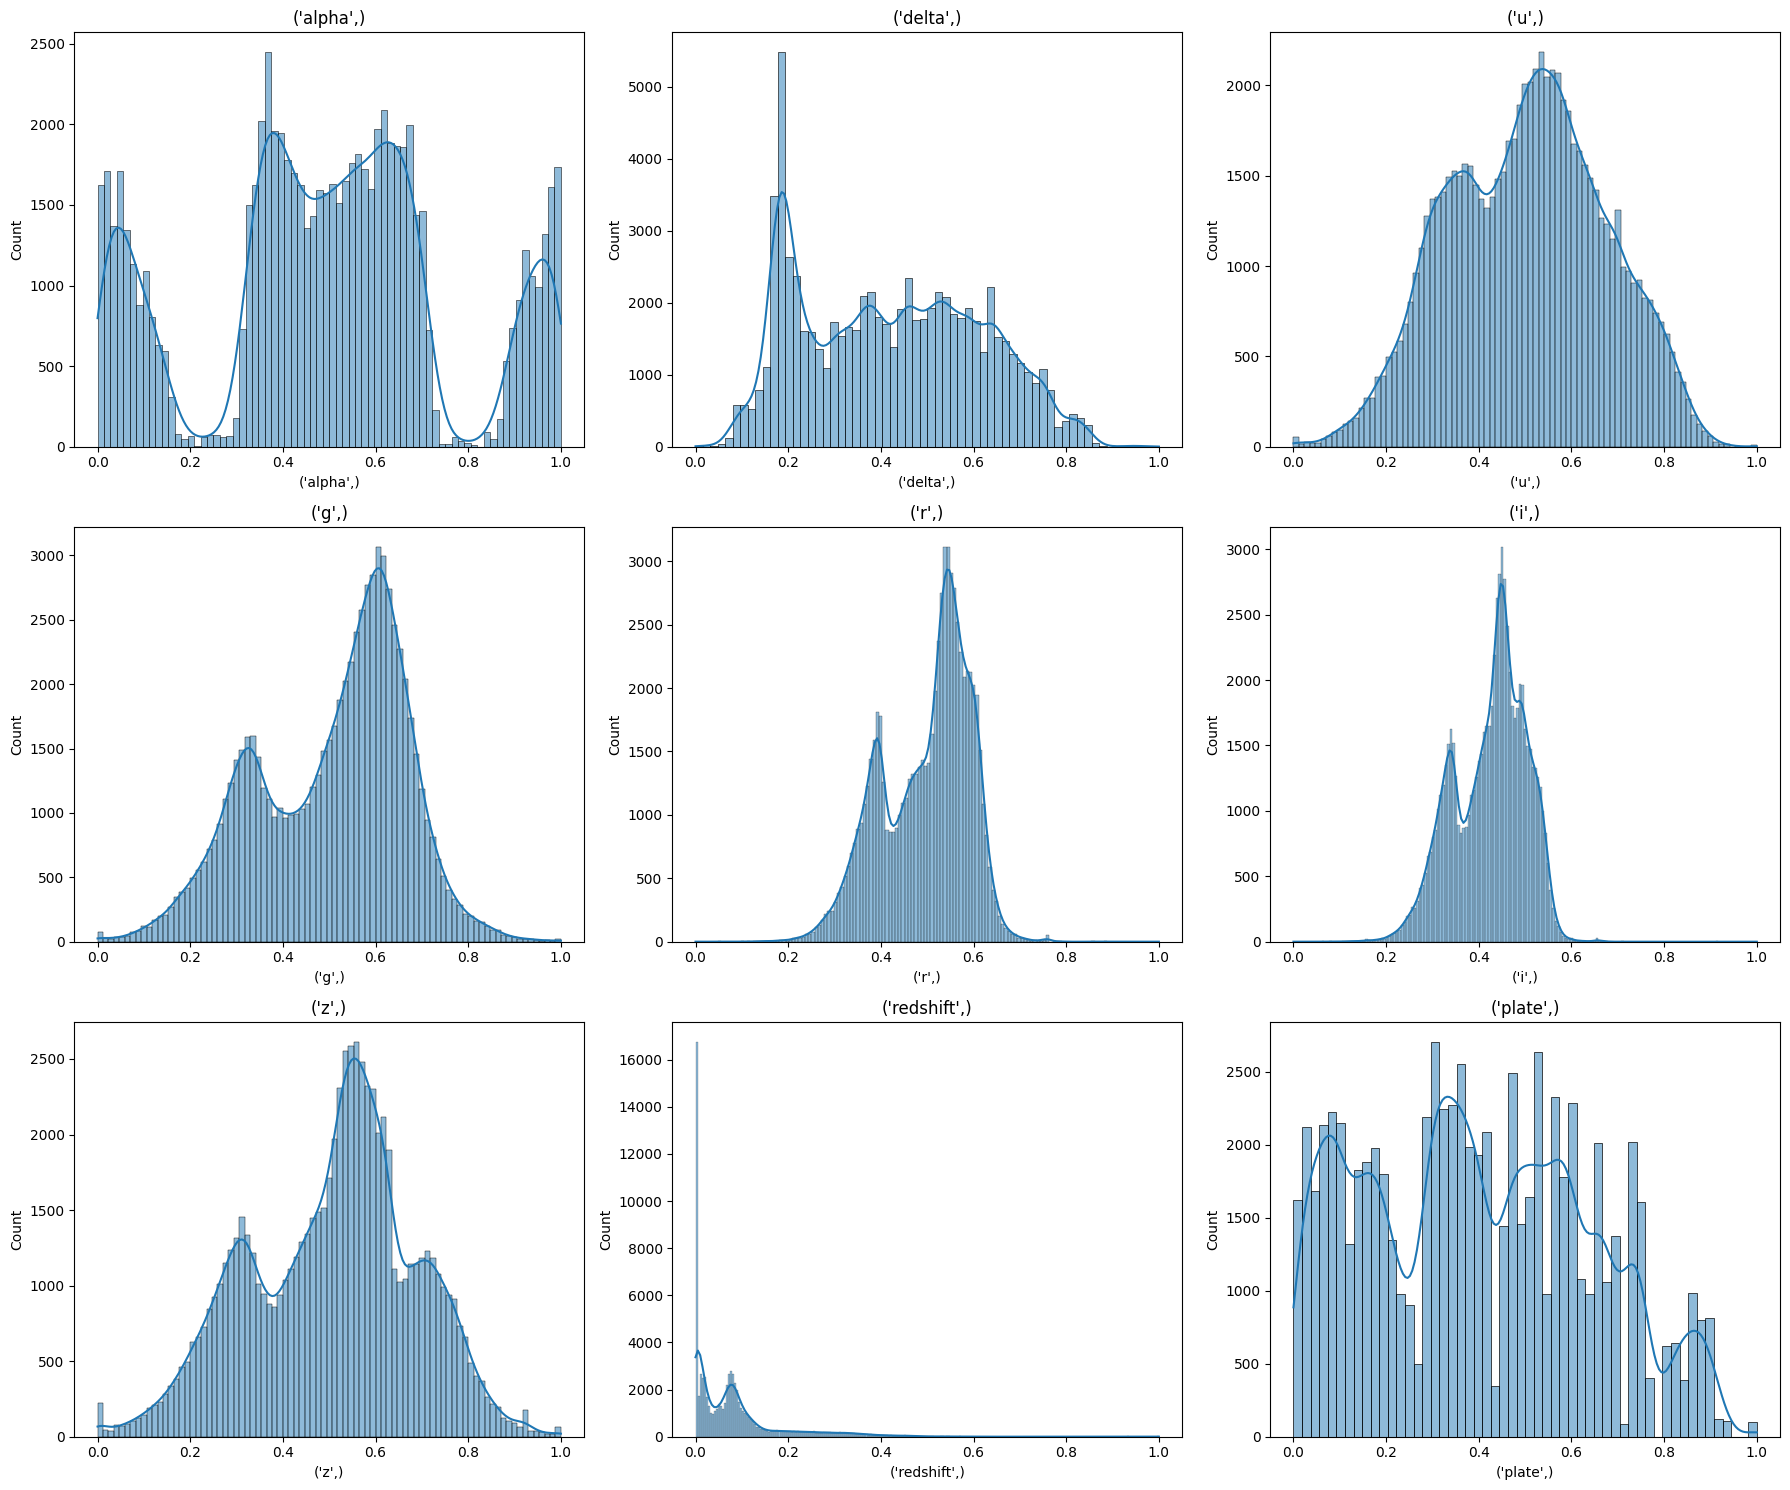

In [22]:
columns = X_train.columns.values
plot_histograms(pd.DataFrame(X_train_normalized, columns=[columns]))

Choose best hyperparameters.

 A higher C value makes the model aim for fewer misclassifications by using a smaller margin, while a lower C allows more misclassifications with a wider margin.

In [23]:
parameters = {'kernel':('linear', 'rbf', 'poly'), 'C':[0.01, 0.1, 1, 10, 100]}
svc = svm.SVC()
clf = GridSearchCV(svc, parameters, cv=3, n_jobs=-1, verbose=3)
clf.fit(X_train_normalized, y_train)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


GridSearchCV(cv=3, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100],
                         'kernel': ('linear', 'rbf', 'poly')},
             verbose=3)

In [24]:
cv_results_df = pd.DataFrame(clf.cv_results_)
cv_results_df.sort_values(by=['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_C,param_kernel,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
13,51.164872,0.528876,14.014961,0.297071,100.00,rbf,"{'C': 100, 'kernel': 'rbf'}",0.97160,0.97088,0.97048,0.970987,0.000463,1
14,1132.503265,282.061052,4.859193,1.493374,100.00,poly,"{'C': 100, 'kernel': 'poly'}",0.97048,0.97184,0.96980,0.970707,0.000848,2
11,184.287166,1.124360,7.077612,0.375501,10.00,poly,"{'C': 10, 'kernel': 'poly'}",0.96820,0.96912,0.96712,0.968147,0.000817,3
10,34.095066,0.747620,19.434291,0.513078,10.00,rbf,"{'C': 10, 'kernel': 'rbf'}",0.96632,0.96648,0.96584,0.966213,0.000272,4
8,59.823270,0.506618,9.528057,0.794611,1.00,poly,"{'C': 1, 'kernel': 'poly'}",0.96212,0.96304,0.96132,0.962160,0.000703,5
12,78.896960,2.288470,7.427049,0.714616,100.00,linear,"{'C': 100, 'kernel': 'linear'}",0.96032,0.96148,0.95956,0.960453,0.000789,6
7,45.525509,1.254447,31.827170,0.371032,1.00,rbf,"{'C': 1, 'kernel': 'rbf'}",0.95624,0.95644,0.95516,0.955947,0.000562,7
5,49.952270,0.952619,14.894538,0.129789,0.10,poly,"{'C': 0.1, 'kernel': 'poly'}",0.95496,0.95468,0.95292,0.954187,0.000903,8
9,50.979788,1.974297,13.322977,0.225683,10.00,linear,"{'C': 10, 'kernel': 'linear'}",0.94876,0.94988,0.94804,0.948893,0.000757,9
6,61.052939,0.154795,21.951705,0.356755,1.00,linear,"{'C': 1, 'kernel': 'linear'}",0.93460,0.93860,0.93580,0.936333,0.001676,10


The best kernel for given dataset is: rbf with C = 100.

In [25]:
y_pred = clf.predict(X_test_normalized)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy score: {accuracy}")

Accuracy score: 0.97128


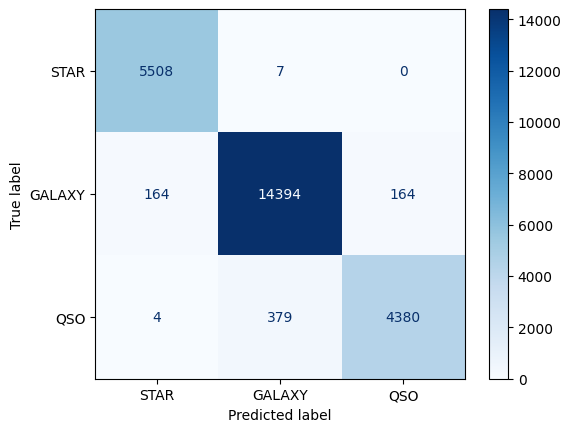

In [28]:
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["STAR", "GALAXY", "QSO"])
disp.plot(cmap='Blues')
plt.show()

#### What values of the confusion matrix should we aim for if we want to use the classifier for automatic selection of objects for telescope observation during the search for new galaxies?



We should aim for the lowest possible number of false negatives (**FN**) — that is, when a real galaxy is classified as another type of object. When searching for as many galaxies as possible, missing any of them is highly undesirable.